In [1]:
# Cell 1: Import our tools
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# A quick helper function to display images in the notebook
def show_image(image_rgb, title="Image"):
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [4]:
import os
print(os.listdir("models"))

['best.ayoub.pt', 'best.pt', 'best_emptying.pt', 'best_emptyingaymane.pt', 'best_emptyingoriginal.pt', 'best_fullness.pt', 'best_fullnessoriginal.pt', 'best_material.pt', 'best_materialoriginal.pt', 'best_night_detector.pt', 'best_size.pt']


In [6]:
# Cell 2: Load our pre-trained brains (No training required!)
print("Loading models...")

# Pointing to the correct 'models' folder
bin_model = YOLO("models/best.pt") 
fullness_model = YOLO("models/best_fullness.pt")
emptying_model = YOLO("models/best_emptying.pt")

print("Models successfully loaded into memory!")

Loading models...
Models successfully loaded into memory!


In [ ]:
# Run this once to extract a test frame from your video!
import cv2
import os

video_path = "C:\\Users\\DELL\\Desktop\\PFE\\emptying-videos\\raw_20260126_222246.mp4"  # Remove trailing space
cap = cv2.VideoCapture(video_path)

# Skip ahead to frame 100 (where bins are usually visible)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100) 
ret, frame = cap.read()

if ret:
    # Save with absolute path to ensure consistency
    test_image_path = "C:\\Users\\DELL\\Desktop\\PFE\\bac-detection-raw\\test_image.jpg"
    cv2.imwrite(test_image_path, frame)
    print(f"Success! Created test_image.jpg at {test_image_path}")
else:
    print("Failed to read the video. Check the video_path!")
    
cap.release()

Success! Created test_image.jpg from your video.



0: 384x640 4 bacs, 329.6ms
Speed: 3.2ms preprocess, 329.6ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


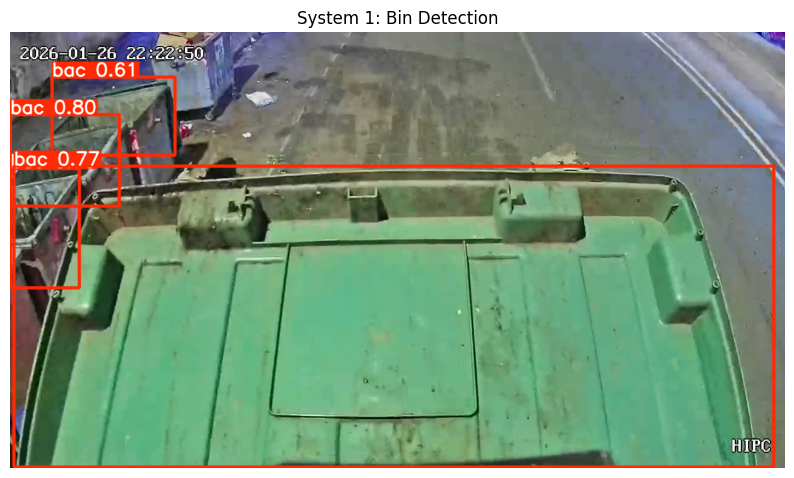

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Ensure show_image is defined (fallback in case Cell 1 wasn't run)
if 'show_image' not in globals():
    def show_image(image_rgb, title="Image"):
        plt.figure(figsize=(10, 8))
        plt.imshow(image_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

# Cell 3: Let's test the bin detector!
image_path = "C:\\Users\\DELL\\Desktop\\PFE\\bac-detection-raw\\test_image.jpg"  # Updated path to match where image is saved
img = cv2.imread(image_path)
# Fall back to the in-memory frame if reading from disk failed
if img is None:
    if 'frame' in globals() and frame is not None:
        img = frame
    else:
        raise FileNotFoundError(f"Could not read image at {image_path} and no in-memory 'frame' available.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Run the model
if 'bin_model' not in globals():
    if 'bin_model' not in globals():
        bin_model = YOLO("models/best.pt")

results = bin_model.predict(img_rgb, conf=0.45)

# Plot the bounding boxes on the image
res_plotted = results[0].plot()

# Show the result right here in the notebook
show_image(res_plotted, "System 1: Bin Detection")

In [28]:
# Cell 4: Let's test the fullness classifier!
from PIL import Image
from ultralytics import YOLO
import os
import cv2

# Load fullness model if not already loaded
if 'fullness_model' not in globals():
    fullness_model = YOLO("models/best_fullness.pt")
    print("Loaded fullness model")

crop_path = "bin_crop.jpg" # Put a cropped image of just a bin here

# Try to load bin_crop.jpg, or extract a crop from the previous detection results
if os.path.exists(crop_path):
    crop = Image.open(crop_path)
    print(f"Loaded crop from {crop_path}")
elif 'results' in globals() and results is not None and results[0].boxes is not None and len(results[0].boxes) > 0:
    # Extract a crop of the first detected bin from the previous results
    print("bin_crop.jpg not found. Extracting crop from previous detection...")
    box = results[0].boxes[0]
    x1, y1, x2, y2 = box.xyxy[0].int().tolist()
    
    # Get the original image and crop it
    crop_array = img_rgb[y1:y2, x1:x2]
    crop = Image.fromarray(crop_array)
    print(f"Extracted crop from detected bin")
else:
    # Re-run detection on the test image to get a crop
    print("bin_crop.jpg not found and no previous detection results. Running detection...")
    image_path = "C:\\Users\\DELL\\Desktop\\PFE\\bac-detection-raw\\test_image.jpg"
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not find test image at {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if 'bin_model' not in globals():
        bin_model = YOLO("models/best.pt")
    
    detection_results = bin_model.predict(img_rgb, conf=0.45)
    
    if detection_results[0].boxes is not None and len(detection_results[0].boxes) > 0:
        box = detection_results[0].boxes[0]
        x1, y1, x2, y2 = box.xyxy[0].int().tolist()
        crop_array = img_rgb[y1:y2, x1:x2]
        crop = Image.fromarray(crop_array)
        print(f"Extracted crop from detected bin")
    else:
        raise FileNotFoundError(f"No bins detected in the test image. Please provide {crop_path}")

results = fullness_model.predict(crop)
prediction = results[0].names[results[0].probs.top1]
confidence = results[0].probs.top1conf.item()

print(f"The AI is {confidence*100:.1f}% sure this bin is: {prediction.upper()}")

bin_crop.jpg not found and no previous detection results. Running detection...

0: 384x640 4 bacs, 542.4ms
Speed: 7.6ms preprocess, 542.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Extracted crop from detected bin

0: 224x224 empty 1.00, full 0.00, 34.6ms
Speed: 3.4ms preprocess, 34.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
The AI is 100.0% sure this bin is: EMPTY
